# Week 4 — Forecasting with ARMA Models

Now we put ARMA to work: estimate models from data, select the best specification using information criteria, and produce forecasts with confidence intervals.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 4.1 Model Estimation with `statsmodels`

In [2]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# Generate ARMA(1,1) data
np.random.seed(42)
from statsmodels.tsa.arima_process import ArmaProcess
true_proc = ArmaProcess(ar=[1, -0.7], ma=[1, 0.3])
y = true_proc.generate_sample(nsample=300)

# Estimate
model = ARIMA(y, order=(1, 0, 1))
result = model.fit()
print(result.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -419.967
Date:                Mon, 10 Aug 2026   AIC                            847.933
Time:                        08:31:01   BIC                            862.748
Sample:                             0   HQIC                           853.862
                                - 300                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0222      0.216     -0.103      0.918      -0.446       0.402
ar.L1          0.6660      0.057     11.708      0.000       0.554       0.777
ma.L1          0.2584      0.077      3.345      0.0

## 4.2 Information Criteria for Model Selection

We compare models using AIC and BIC:

$$\text{AIC} = -2\ell + 2k, \quad \text{BIC} = -2\ell + k \log T$$

  Order        AIC        BIC
ARMA1,1 847.933101 862.748231
ARMA2,1 848.119781 866.638694
ARMA2,0 849.388523 864.203653
ARMA2,2 849.403137 871.625832
ARMA1,0 856.525675 867.637022
ARMA0,2 883.208356 898.023486
ARMA0,1 922.891887 934.003235


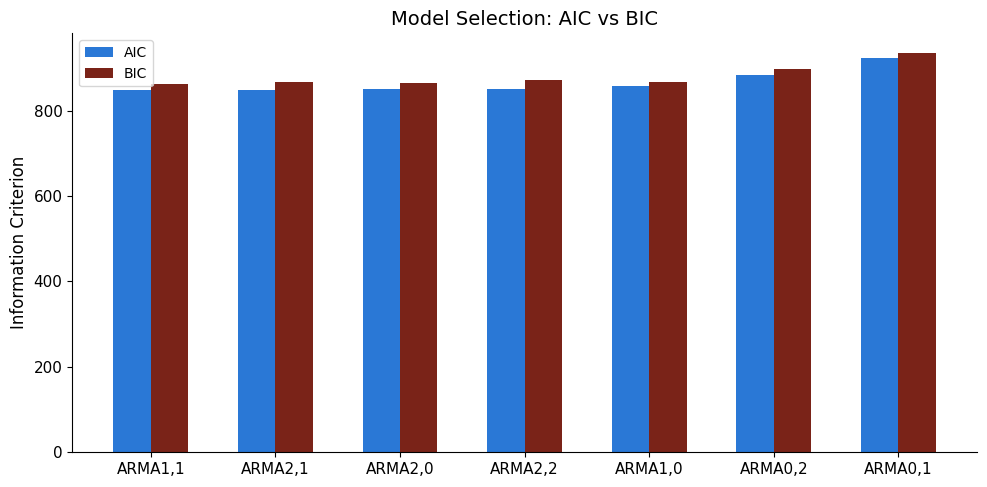

In [3]:
# Compare AIC/BIC across model orders
orders = [(1,0,0), (0,0,1), (1,0,1), (2,0,0), (2,0,1), (0,0,2), (2,0,2)]
results = []
for order in orders:
    try:
        m = ARIMA(y, order=order).fit()
        results.append({'Order': f'ARMA{order[0]},{order[2]}', 'AIC': m.aic, 'BIC': m.bic})
    except:
        pass

import pandas as pd
df = pd.DataFrame(results).sort_values('AIC')
print(df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df))
ax.bar([i - 0.15 for i in x], df['AIC'], width=0.3, color=UOE_BLUE, label='AIC')
ax.bar([i + 0.15 for i in x], df['BIC'], width=0.3, color=UOE_RED, label='BIC')
ax.set_xticks(list(x))
ax.set_xticklabels(df['Order'])
ax.set_ylabel('Information Criterion')
ax.set_title('Model Selection: AIC vs BIC')
ax.legend()
plt.tight_layout()
plt.show()


## 4.3 Forecasting and Confidence Intervals

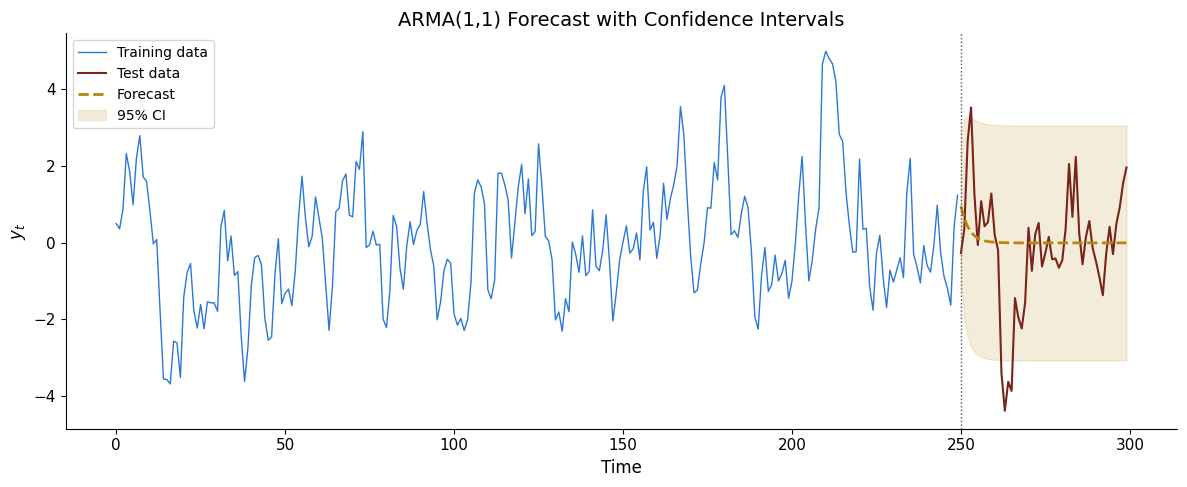

Out-of-sample RMSE: 1.5282


In [4]:
# Split and forecast
train, test = y[:250], y[250:]
model = ARIMA(train, order=(1, 0, 1)).fit()
fc = model.get_forecast(steps=50)
ci = fc.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(250), train, color=UOE_BLUE, label='Training data', lw=1)
ax.plot(range(250, 300), test, color=UOE_RED, label='Test data', lw=1.5)
ax.plot(range(250, 300), fc.predicted_mean, '--', color=UOE_GOLD, lw=2, label='Forecast')
ax.fill_between(range(250, 300), ci.values[:, 0] if hasattr(ci, 'values') else ci[:, 0], ci.values[:, 1] if hasattr(ci, 'values') else ci[:, 1],
                alpha=0.15, color=UOE_GOLD, label='95% CI')
ax.axvline(250, ls=':', color=UOE_GREY, lw=1)
ax.set_xlabel('Time')
ax.set_ylabel('$y_t$')
ax.set_title('ARMA(1,1) Forecast with Confidence Intervals')
ax.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((test - fc.predicted_mean)**2))
print(f"Out-of-sample RMSE: {rmse:.4f}")


## 4.4 Residual Diagnostics

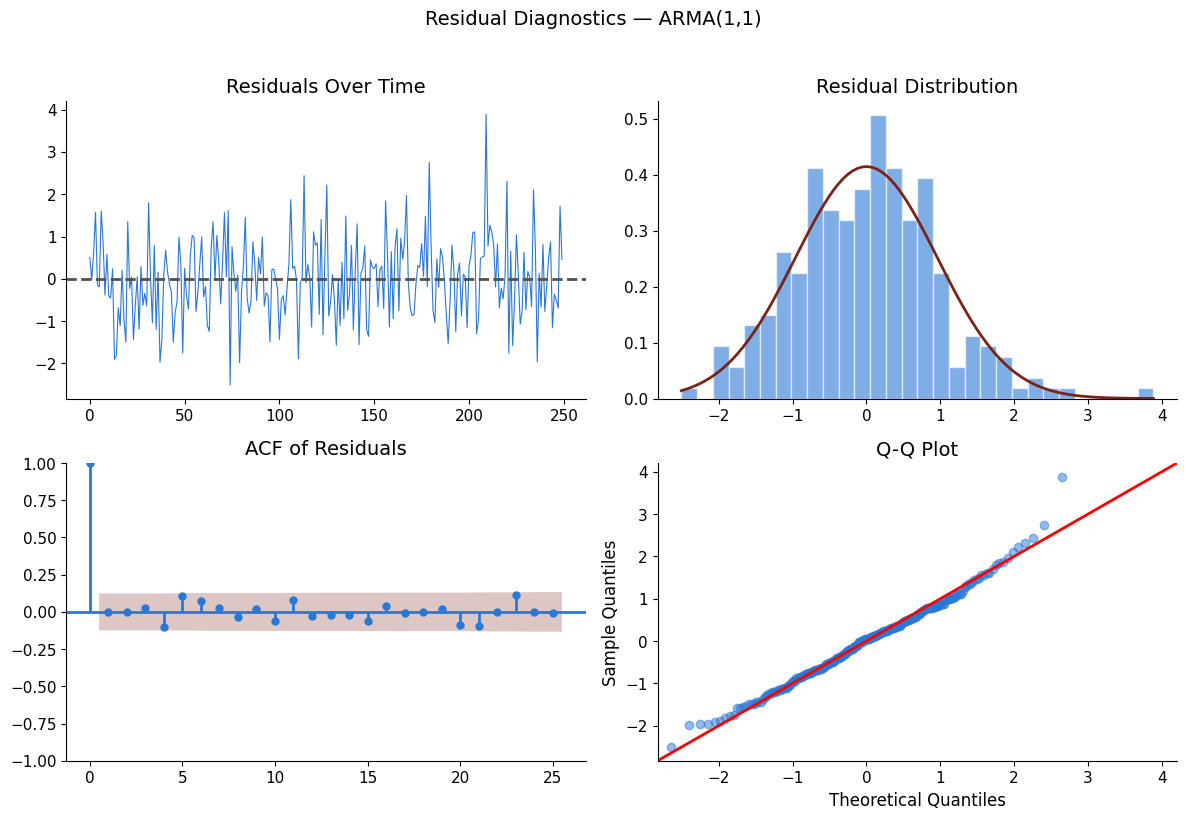

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm
import statsmodels.api as sm

residuals = model.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(residuals, color=UOE_BLUE, lw=0.8)
axes[0, 0].axhline(0, ls='--', color=UOE_GREY)
axes[0, 0].set_title('Residuals Over Time')

axes[0, 1].hist(residuals, bins=30, density=True, alpha=0.6,
                color=UOE_BLUE, edgecolor='white')
x_r = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x_r, norm.pdf(x_r, residuals.mean(), residuals.std()),
                color=UOE_RED, lw=2)
axes[0, 1].set_title('Residual Distribution')

plot_acf(residuals, lags=25, ax=axes[1, 0], color=UOE_BLUE,
         vlines_kwargs={'color': UOE_BLUE})
axes[1, 0].set_title('ACF of Residuals')

sm.qqplot(residuals, line='45', ax=axes[1, 1],
          markerfacecolor=UOE_BLUE, markeredgecolor=UOE_BLUE, alpha=0.5)
axes[1, 1].set_title('Q-Q Plot')

plt.suptitle('Residual Diagnostics — ARMA(1,1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Use a rolling-window forecast to evaluate an AR(2) model.</summary>

```python
window = 200
forecasts = []
actuals = []
for t in range(window, len(y)-1):
    m = ARIMA(y[:t], order=(2,0,0)).fit()
    fc = m.forecast(steps=1)
    forecasts.append(fc[0])
    actuals.append(y[t])
rmse = np.sqrt(np.mean((np.array(actuals) - np.array(forecasts))**2))
print(f'Rolling RMSE: {rmse:.4f}')
```
</details>